# Healthcare RAG: Retrieval Architecture Comparison & Ablation

This notebook compares three retrieval architectures over a synthetic healthcare
corpus, ablates the pieces that are usually asserted rather than measured, and
evaluates the generation stage on citation honesty and abstention.

```
query -> embedder -> vector store -> retrieval_k candidates
                                        |
                                   second stage (rerank)
                                        |
                                   context_k passages -> LLM -> cited answer
```

**Everything here runs for real.** Dense retrieval uses `sentence-transformers`
(all-MiniLM-L6-v2), the reranker is a real cross-encoder
(`ms-marco-MiniLM-L-6-v2`), and the vector store can be a real Milvus Lite
collection (`python3 experiment.py --milvus`, verified to return rankings
identical to exact search). The one exception is the LLM: with no API
credentials present, generation falls back to a deterministic extractive
baseline, which is labeled as such wherever it appears.

### What this notebook is designed to show

| Question | Where |
|---|---|
| Does dense retrieval beat lexical, and on which queries? | §4, §5 |
| Does a cross-encoder reranker actually help? | §6, §8 |
| Is BM25-as-reranker a fair second stage? | §6 (it is not - it *hurts*) |
| Why must `retrieval_k` and `context_k` be separate? | §8 |
| Does the system decline when it has no source? | §10 |

## 1. Setup

Note the environment check: the previous version of this project reported that
`sentence-transformers`, `pymilvus`, and a hosted LLM were all unavailable and
substituted stand-ins for each. Two of those three are in fact available here,
so the stand-ins have been replaced with the real components.

In [1]:
import sys
import numpy as np, pandas as pd, matplotlib
print(sys.version.split()[0])
for module in ("numpy", "pandas", "matplotlib", "sklearn", "torch", "sentence_transformers"):
    try:
        loaded = __import__(module)
        print(f"  {module:<24} {getattr(loaded, '__version__', 'n/a')}")
    except ImportError:
        print(f"  {module:<24} NOT AVAILABLE")

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda v: f"{v:0.3f}")

3.12.1
  numpy                    1.26.4
  pandas                   2.2.1
  matplotlib               3.9.3


  sklearn                  1.4.1.post1


  torch                    2.2.1


  sentence_transformers    2.6.0


## 2. The evaluation set

A retrieval eval is only as informative as its hard negatives. The corpus is
built with deliberate **distractor families** - clusters of passages sharing a
query's surface vocabulary while answering a different question - so that a
retriever cannot score well by keyword overlap alone.

Labels are **graded**: `2` = directly answers the question, `1` = useful
supporting context. Binary metrics threshold at `>= 1`; NDCG uses the grades, so
retrieving the passage that actually answers the question outranks retrieving
one that is merely adjacent.

Ten queries are **unanswerable** by design (no passage covers them). They are
not retrieval failures - they are abstention tests, and they are excluded from
retrieval metrics (recall is undefined) and scored separately in §10.

In [2]:
from collections import Counter
from data import CORPUS, QUERIES, validate, answerable_queries

stats = validate()   # raises if any label points at a non-existent passage
print(stats)
print("\nqueries by kind:", dict(Counter(q["kind"] for q in QUERIES)))

{'documents': 127, 'topics': 14, 'queries': 95, 'answerable': 85, 'unanswerable': 10, 'labels': 159}

queries by kind: {'direct': 30, 'paraphrase': 25, 'distractor': 20, 'multi_doc': 10, 'unanswerable': 10}


In [3]:
# A distractor family: four passages that all match "first-line therapy",
# each answering a different question. Only DM04 answers a type 2 query.
for doc in CORPUS:
    if doc["id"] in {"DM04", "DM05", "DM06", "DM07"}:
        print(f"[{doc['id']}] {doc['text'][:118]}...")

print("\nA graded, multi-document query:")
example = next(q for q in QUERIES if q["kind"] == "multi_doc")
print(f"  {example['query']!r}")
print(f"  labels: {example['relevant']}   (2 = answers it, 1 = supporting)")

[DM04] First-line pharmacologic therapy for most adults with type 2 diabetes is metformin, started alongside lifestyle change...
[DM05] First-line therapy for type 1 diabetes is insulin replacement, delivered either as multiple daily injections of basal ...
[DM06] When metformin alone does not achieve the glucose target, second-line options added on top of it include SGLT2 inhibit...
[DM07] Gestational diabetes is managed first with medical nutrition therapy and glucose self-monitoring; when targets are not...

A graded, multi-document query:
  'What lifestyle changes lower blood pressure?'
  labels: {'HT04': 2, 'HT05': 2, 'LS06': 2, 'LS02': 1, 'LS07': 1, 'LS05': 1, 'LS01': 1}   (2 = answers it, 1 = supporting)


## 3. Components and the responsibility boundary

The contract is `contracts.py`. The boundary worth calling out:

```python
vector     = embedder.embed_query(text)      # text   -> vector
candidates = store.search(vector, top_k)     # vector -> documents
```

An earlier version had `VectorStore.search(query_text, top_k)`, which implies
the store embeds text - and in that version the store did exactly that, by
holding a reference to the embedder and reaching into its document matrix. The
two objects were one object with two names. A real Milvus server cannot embed
text for you, so that interface could never have been swapped for the thing it
was standing in for. `DenseRetriever` now owns the two-step composition.

In [4]:
from experiment import build_components, build_arms, RETRIEVAL_K, CONTEXT_K

components = build_components()
arms = build_arms(components, RETRIEVAL_K, CONTEXT_K)
queries = answerable_queries()
for name, pipeline in arms.items():
    print(f"  {name}")

Loading components ...


  vector store: numpy-exact


  dense embedder: dense[all-MiniLM-L6-v2] (384-d)
  reranker: cross-encoder[ms-marco-MiniLM-L-6-v2]
  A. Lexical retrieval (BM25 only)
  B. Dense retrieval (no reranker)
  C. Dense + cross-encoder reranker
  D. Dense + lexical second-stage rerank (baseline)


### A single query, end to end

This is the reranker doing the one thing it is supposed to do.

In [5]:
query = "What is the first-line medication for type 2 diabetes?"
gold = next(q for q in QUERIES if q["query"] == query)["relevant"]
result = arms["C. Dense + cross-encoder reranker"].run(query, generate=False)

print(f"QUERY: {query}\nGOLD:  {gold}\n")
print("Stage 1 - dense retrieval (top 5 of retrieval_k=20):")
for candidate in result.retrieved[:5]:
    mark = "<-- correct" if gold.get(candidate.id) == 2 else ""
    print(f"  {candidate.id}  cos={candidate.retrieval_score:.3f}  {candidate.text[:64]}... {mark}")

print("\nStage 2 - after the cross-encoder:")
for candidate in result.reranked[:5]:
    mark = "<-- correct" if gold.get(candidate.id) == 2 else ""
    print(f"  {candidate.id}  logit={candidate.rerank_score:+.2f}  {candidate.text[:64]}... {mark}")

print(f"\ncontext_k={result.context_k} passages sent to the LLM: {result.context_ids}")
print("timings (ms):", {k: round(v, 2) for k, v in result.timings_ms.items()})

QUERY: What is the first-line medication for type 2 diabetes?
GOLD:  {'DM04': 2, 'DM06': 1}

Stage 1 - dense retrieval (top 5 of retrieval_k=20):
  DM05  cos=0.667  First-line therapy for type 1 diabetes is insulin replacement, d... 
  DM04  cos=0.661  First-line pharmacologic therapy for most adults with type 2 dia... <-- correct
  DM06  cos=0.586  When metformin alone does not achieve the glucose target, second... 
  DM01  cos=0.538  Type 2 diabetes is diagnosed with a fasting plasma glucose of 12... 
  CV11  cos=0.462  Heart failure with reduced ejection fraction is treated with fou... 

Stage 2 - after the cross-encoder:
  DM04  logit=+9.82  First-line pharmacologic therapy for most adults with type 2 dia... <-- correct
  DM05  logit=+6.77  First-line therapy for type 1 diabetes is insulin replacement, d... 
  CV02  logit=+0.53  Statins are the first-line drug class for lowering LDL cholester... 
  MH05  logit=+0.37  Selective serotonin reuptake inhibitors are the usual first-line.

Dense retrieval ranks **DM05** (first-line therapy for type **1** diabetes)
above **DM04** (the correct type 2 passage) - the distractor shares nearly every
content word with the query. The cross-encoder, which encodes the query and
passage *jointly*, separates them decisively.

This is also why `recall@1` and `primary_hit@1` are in the metric set. Recall@5
is identical before and after this fix, so a harness that only reported @5 would
call this a non-event.

## 4. Metrics

- **Recall@k** - did the relevant material reach the candidate set at all?
- **Recall@1 / primary_hit@1** - is the best passage already on top?
  `primary_hit@1` requires a *gain-2* passage at rank 1, so adjacent context
  does not earn credit.
- **MRR@10** - how far down before the first relevant hit.
- **NDCG@5/@10** - rank-weighted and grade-aware.
- **Precision@k** - reported, but as a *context-efficiency* measure. With one or
  two relevant passages per query, precision@10 is arithmetically capped near
  0.1; a "precision drop" from k=3 to k=10 measures the label distribution, not
  the retriever.
- **context_recall** - recall restricted to the `context_k` passages the LLM
  actually receives. Anything outside it cannot be cited, so this bounds answer
  quality.

`test_metrics.py` checks each of these against hand-computed values.

## 5. Architecture comparison

Three architectures, plus one ablation arm:

| Arm | First stage | Second stage |
|---|---|---|
| **A** | BM25 lexical | none |
| **B** | dense bi-encoder | none |
| **C** | dense bi-encoder | **cross-encoder reranker** |
| **D** | dense bi-encoder | **lexical second-stage reranking baseline (BM25)** |

Arm D is named carefully. BM25 is a lexical retrieval/scoring function, not a
neural cross-encoder; using it in second position is legitimate but it is a
*baseline*, and it is included because it is nearly free and therefore sets the
bar the neural model must clear.

In [6]:
from experiment import run_architecture_comparison

summary, per_query_frames = run_architecture_comparison(arms, queries, RETRIEVAL_K, CONTEXT_K)
summary[["architecture", "recall@1", "recall@3", "recall@5", "recall@10",
         "primary_hit@1", "mrr@10", "ndcg@5", "ndcg@10", "context_recall"]]

  evaluating: A. Lexical retrieval (BM25 only)


  evaluating: B. Dense retrieval (no reranker)


  evaluating: C. Dense + cross-encoder reranker


  evaluating: D. Dense + lexical second-stage rerank (baseline)


,architecture,recall@1,recall@3,recall@5,recall@10,primary_hit@1,mrr@10,ndcg@5,ndcg@10,context_recall
0,A. Lexical retrieval (BM25 only),0.418,0.572,0.618,0.689,0.612,0.709,0.647,0.668,0.618
1,B. Dense retrieval (no reranker),0.558,0.819,0.890,0.930,0.800,0.922,0.875,0.888,0.890
2,C. Dense + cross-encoder reranker,0.568,0.807,0.880,0.926,0.847,0.924,0.879,0.893,0.880
3,D. Dense + lexical second-stage rerank (baseline),0.444,0.614,0.668,0.813,0.647,0.768,0.696,0.739,0.668


### By query kind

The overall means hide where each component earns its cost.

In [7]:
all_per_query = pd.concat(per_query_frames.values(), ignore_index=True)
short = {name: name.split(".")[0] for name in per_query_frames}
all_per_query["arm"] = all_per_query["architecture"].map(short)

for metric in ("ndcg@5", "recall@1"):
    print(f"\n{metric} by query kind:")
    print(all_per_query.pivot_table(index="kind", columns="arm", values=metric, aggfunc="mean").to_string())


ndcg@5 by query kind:
arm            A     B     C     D
kind                              
direct     0.860 0.931 0.938 0.879
distractor 0.742 0.909 0.898 0.753
multi_doc  0.424 0.761 0.772 0.472
paraphrase 0.403 0.827 0.836 0.519

recall@1 by query kind:
arm            A     B     C     D
kind                              
direct     0.633 0.683 0.667 0.633
distractor 0.400 0.500 0.525 0.400
multi_doc  0.150 0.289 0.275 0.225
paraphrase 0.280 0.560 0.600 0.340


Two readings:

- **The `paraphrase` slice is the whole case for dense retrieval.** Lexical
  retrieval scores ~0.40 NDCG@5 there against ~0.83 for dense; on `direct`
  queries the gap is far smaller. Queries phrased in patient vocabulary
  ("water pill", "puffer", "sugar levels") are exactly what a lexical retriever
  cannot match, and exactly what real users type.
- **The lexical second stage (D) claws back some of BM25's paraphrase weakness
  but drags the dense arm down everywhere else.** It is re-imposing lexical
  overlap on a candidate set that was retrieved semantically.

## 6. Is any of this significant?

With 85 queries, a few points of difference is noise. Every comparison the
architecture rests on gets a paired bootstrap over the same queries.

In [8]:
from experiment import run_significance_tests

significance = run_significance_tests(per_query_frames)
significance.drop(columns=["arm_a", "arm_b"])

,comparison,metric,mean_a,mean_b,difference,ci_low,ci_high,significant
0,dense vs lexical retrieval,recall@1,0.558,0.418,0.140,0.058,0.224,True
1,dense vs lexical retrieval,primary_hit@1,0.800,0.612,0.188,0.059,0.318,True
2,dense vs lexical retrieval,ndcg@5,0.875,0.647,0.229,0.159,0.304,True
3,dense vs lexical retrieval,mrr@10,0.922,0.709,0.213,0.130,0.301,True
4,dense vs lexical retrieval,context_recall,0.890,0.618,0.272,0.195,0.356,True
5,cross-encoder vs no reranker,recall@1,0.568,0.558,0.010,-0.043,0.063,False
6,cross-encoder vs no reranker,primary_hit@1,0.847,0.800,0.047,-0.047,0.141,False
7,cross-encoder vs no reranker,ndcg@5,0.879,0.875,0.004,-0.035,0.040,False
8,cross-encoder vs no reranker,mrr@10,0.924,0.922,0.002,-0.043,0.046,False
9,cross-encoder vs no reranker,context_recall,0.880,0.890,-0.010,-0.056,0.031,False


Three findings, in descending order of how much they should change your design:

1. **Dense > lexical is real and large** (+0.14 recall@1, +0.23 NDCG@5, CIs
   well clear of zero).
2. **BM25 as a second stage is significantly *worse* than no second stage at
   all** (-0.11 recall@1, -0.22 context_recall; CI entirely below zero). This is
   the concrete reason not to call BM25 "the reranker" - measured on the same
   queries against the same first stage, it is a net negative. Its job here is
   to be the honest baseline that shows why a *neural* second stage is the one
   worth paying for.
3. **The cross-encoder's gain over no reranker is not significant on this
   corpus** (+0.010 recall@1, +0.047 primary_hit@1, CIs straddle zero). It
   wins every point estimate and it fixed the DM04/DM05 case in §3, but at
   n=85 with a 127-document corpus the dense retriever is already finding the
   right passage inside the top 5 about 89% of the time, so there is very
   little headroom left to reorder. §8 shows where that changes.

Reporting (3) as a win would be the easiest thing to do and the wrong thing to
do. The correct conclusion is that a cross-encoder is not free architecture
insurance - its value depends on how much the first stage is leaving on the
table, which is measured next.

## 7. Latency

In [9]:
from experiment import run_latency

latency = run_latency(arms, queries, RETRIEVAL_K, CONTEXT_K, repeats=3)
latency

,architecture,retrieve_mean_ms,rerank_mean_ms,total_mean_ms,total_p50_ms,total_p95_ms,n_samples
0,A. Lexical retrieval (BM25 only),0.347,0.002,0.350,0.314,0.588,255
1,B. Dense retrieval (no reranker),18.522,0.005,18.527,18.019,24.340,255
2,C. Dense + cross-encoder reranker,18.065,43.260,61.325,58.654,79.260,255
3,D. Dense + lexical second-stage rerank (baseline),19.842,0.151,19.993,18.019,32.640,255


The cross-encoder costs ~40 ms of CPU at `retrieval_k=20` - roughly 3x the total
latency of the dense-only arm, for a gain that section 6 could not distinguish
from zero on this corpus. On a GPU, or against a larger corpus where the first
stage leaves more headroom, that trade looks different; the harness is here so
the decision can be re-measured rather than assumed.

Warmup is discarded before timing. The first call into a torch model pays lazy
kernel initialization and can be an order of magnitude slower than steady state,
which would otherwise be attributed to whichever arm happened to run first.

## 8. The ablation that needs `retrieval_k` != `context_k`

This is the structural fix. If you retrieve `k`, rerank those same `k`, and
evaluate at `k`, then reordering cannot change the set - recall@k and
precision@k are **mathematically identical** with the reranker on or off. The
previous version of this project did exactly that, which made its reranker
results unfalsifiable: every number it reported was the same with the reranker
disabled.

A second stage can only act in the gap between the two numbers. Below,
`context_k` is pinned at 5 while `retrieval_k` widens - so the `retrieval_k=5`
row is the degenerate case where all three arms must coincide, and they do.

In [10]:
from experiment import run_retrieval_k_ablation

k_ablation = run_retrieval_k_ablation(components, queries, context_k=CONTEXT_K)
k_ablation[["reranker", "retrieval_k", "context_k", "context_recall", "recall@1",
            "primary_hit@1", "ndcg@5", "rerank_mean_ms", "total_mean_ms"]]

  retrieval_k= 5 context_k=5 reranker=none                         context_recall=0.890 recall@1=0.558 total=19.4ms


  retrieval_k=10 context_k=5 reranker=none                         context_recall=0.890 recall@1=0.558 total=20.4ms


  retrieval_k=20 context_k=5 reranker=none                         context_recall=0.890 recall@1=0.558 total=24.7ms


  retrieval_k=50 context_k=5 reranker=none                         context_recall=0.890 recall@1=0.558 total=19.2ms


  retrieval_k= 5 context_k=5 reranker=lexical second stage (BM25)  context_recall=0.890 recall@1=0.503 total=22.1ms


...

  retrieval_k= 5 context_k=5 reranker=cross-encoder                context_recall=0.890 recall@1=0.589 total=46.9ms


  retrieval_k=10 context_k=5 reranker=cross-encoder                context_recall=0.872 recall@1=0.579 total=48.8ms


  retrieval_k=20 context_k=5 reranker=cross-encoder                context_recall=0.880 recall@1=0.568 total=78.7ms


  retrieval_k=50 context_k=5 reranker=cross-encoder                context_recall=0.878 recall@1=0.568 total=102.6ms


,reranker,retrieval_k,context_k,context_recall,recall@1,primary_hit@1,ndcg@5,rerank_mean_ms,total_mean_ms
0,none,5,5,0.890,0.558,0.800,0.875,0.003,19.388
1,none,10,5,0.890,0.558,0.800,0.875,0.004,20.448
2,none,20,5,0.890,0.558,0.800,0.875,0.007,24.715
3,none,50,5,0.890,0.558,0.800,0.875,0.011,19.186
4,lexical second stage (BM25),5,5,0.890,0.503,0.729,0.828,0.069,22.142
5,lexical second stage (BM25),10,5,0.746,0.456,0.659,0.741,0.158,19.557
6,lexical second stage (BM25),20,5,0.668,0.444,0.647,0.696,0.145,17.516
7,lexical second stage (BM25),50,5,0.645,0.418,0.612,0.666,0.266,17.407
8,cross-encoder,5,5,0.890,0.589,0.894,0.900,28.703,46.922
9,cross-encoder,10,5,0.872,0.579,0.859,0.881,30.879,48.766


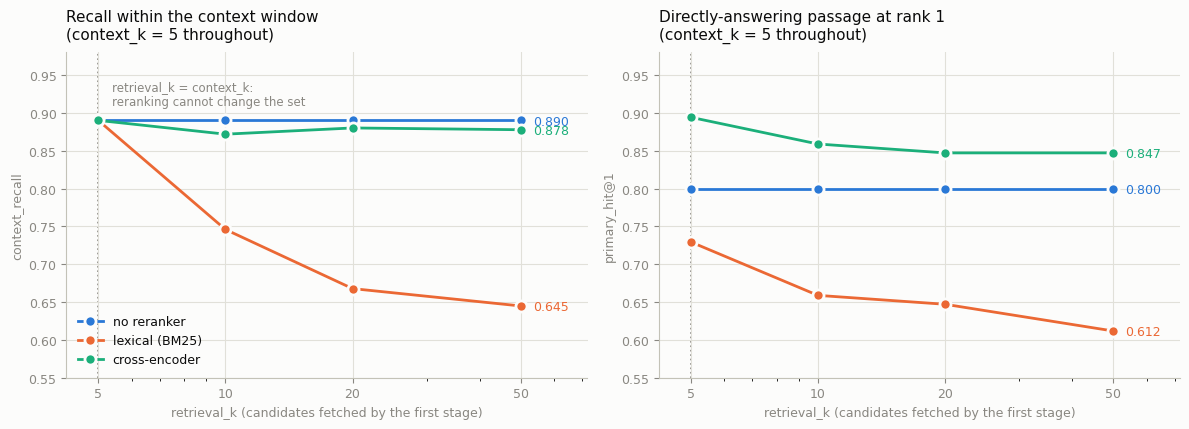

In [11]:
import matplotlib.pyplot as plt

SURFACE, INK, MUTED, GRID = "#fcfcfb", "#0b0b0b", "#898781", "#e1e0d9"
SERIES = {"none": "#2a78d6", "lexical second stage (BM25)": "#eb6834", "cross-encoder": "#1baf7a"}
LABEL = {"none": "no reranker", "lexical second stage (BM25)": "lexical (BM25)", "cross-encoder": "cross-encoder"}

fig, axes = plt.subplots(1, 2, figsize=(12, 4.4), facecolor=SURFACE)
for axis, metric, title in zip(
    axes,
    ("context_recall", "primary_hit@1"),
    ("Recall within the context window", "Directly-answering passage at rank 1"),
):
    axis.set_facecolor(SURFACE)
    for reranker, color in SERIES.items():
        series = k_ablation[k_ablation["reranker"] == reranker].sort_values("retrieval_k")
        axis.plot(series["retrieval_k"], series[metric], color=color, linewidth=2,
                  marker="o", markersize=8, markeredgecolor=SURFACE, markeredgewidth=2,
                  label=LABEL[reranker], zorder=3)
        last = series.iloc[-1]
        axis.annotate(f"{last[metric]:.3f}", (last["retrieval_k"], last[metric]),
                      textcoords="offset points", xytext=(9, -3), color=color,
                      fontsize=9, fontweight="medium")
    axis.set_title(f"{title}\n(context_k = 5 throughout)", color=INK, fontsize=11, loc="left", pad=10)
    axis.set_xlabel("retrieval_k (candidates fetched by the first stage)", color=MUTED, fontsize=9)
    axis.set_ylabel(metric, color=MUTED, fontsize=9)
    axis.set_xscale("log")
    axis.set_xticks([5, 10, 20, 50])
    axis.get_xaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
    axis.set_xlim(4.2, 72)
    axis.set_ylim(0.55, 0.98)
    axis.grid(True, color=GRID, linewidth=0.8, zorder=0)
    axis.tick_params(colors=MUTED, labelsize=9)
    for side in ("top", "right"):
        axis.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        axis.spines[side].set_color("#c3c2b7")

for axis in axes:
    axis.axvline(5, color=MUTED, linestyle=":", linewidth=1.2, zorder=1)
axes[0].annotate("retrieval_k = context_k:\nreranking cannot change the set",
                 (5, 0.955), textcoords="offset points", xytext=(10, -6),
                 color=MUTED, fontsize=8.5, va="top")
axes[0].legend(frameon=False, loc="lower left", fontsize=9, labelcolor=INK)
plt.tight_layout()
plt.show()

Read the left panel from `retrieval_k=5` rightward:

- At `retrieval_k = context_k = 5` all three arms sit at **0.890**, identical -
  the degenerate case, exactly as predicted. Any harness reporting a reranker
  gain here is reporting an artifact.
- Widening the first stage does **not** help the no-reranker arm at all (flat at
  0.890): its top 5 is its top 5 regardless of how many candidates were fetched
  behind them.
- The **lexical second stage degrades monotonically** as the pool widens
  (0.890 -> 0.645). This is the mechanism made visible: a wider pool hands BM25
  more lexically-similar distractors to promote, and it takes them.
- The **cross-encoder holds** its quality as the pool widens (0.890 -> 0.878)
  while its cost grows linearly (~23 ms -> ~76 ms). On this corpus it is
  paying for robustness it does not need; the dense first stage has already
  found the answer.

### 8b. `context_k`: the other half of the split

`retrieval_k` governs retrieval quality. `context_k` governs how much of the
prompt is spent, and how much irrelevant text the model must ignore. Conflating
them means you cannot tune either.

In [12]:
from experiment import run_context_k_ablation

context_ablation = run_context_k_ablation(components, queries, retrieval_k=RETRIEVAL_K)
context_ablation[["retrieval_k", "context_k", "context_recall", "context_precision",
                  "recall@1", "ndcg@5"]]

,retrieval_k,context_k,context_recall,context_precision,recall@1,ndcg@5
0,20,1,0.568,0.882,0.568,0.879
1,20,3,0.807,0.459,0.568,0.879
2,20,5,0.880,0.311,0.568,0.879
3,20,10,0.926,0.166,0.568,0.879


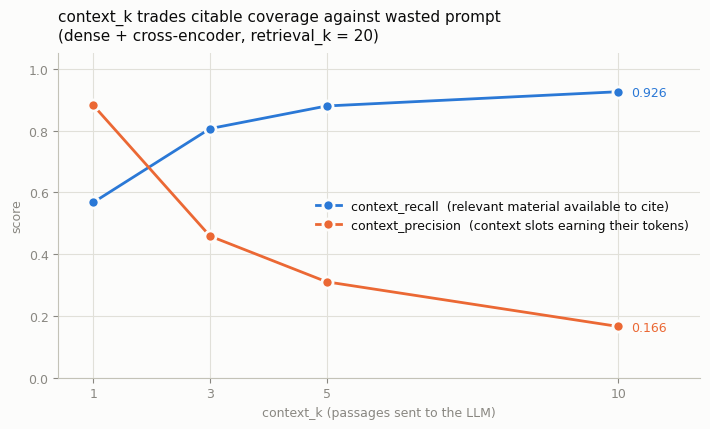

In [13]:
fig, axis = plt.subplots(figsize=(7.2, 4.4), facecolor=SURFACE)
axis.set_facecolor(SURFACE)
lines = [
    ("context_recall", "#2a78d6", "context_recall  (relevant material available to cite)"),
    ("context_precision", "#eb6834", "context_precision  (context slots earning their tokens)"),
]
for column, color, label in lines:
    axis.plot(context_ablation["context_k"], context_ablation[column], color=color,
              linewidth=2, marker="o", markersize=8, markeredgecolor=SURFACE,
              markeredgewidth=2, label=label, zorder=3)
    last = context_ablation.iloc[-1]
    axis.annotate(f"{last[column]:.3f}", (last["context_k"], last[column]),
                  textcoords="offset points", xytext=(9, -3), color=color,
                  fontsize=9, fontweight="medium")
axis.set_title("context_k trades citable coverage against wasted prompt\n"
               "(dense + cross-encoder, retrieval_k = 20)",
               color=INK, fontsize=11, loc="left", pad=10)
axis.set_xlabel("context_k (passages sent to the LLM)", color=MUTED, fontsize=9)
axis.set_ylabel("score", color=MUTED, fontsize=9)
axis.set_xticks(context_ablation["context_k"])
axis.set_xlim(0.4, 11.4)
axis.set_ylim(0, 1.05)
axis.grid(True, color=GRID, linewidth=0.8, zorder=0)
axis.tick_params(colors=MUTED, labelsize=9)
for side in ("top", "right"):
    axis.spines[side].set_visible(False)
for side in ("left", "bottom"):
    axis.spines[side].set_color("#c3c2b7")
axis.legend(frameon=False, loc="center right", fontsize=9, labelcolor=INK)
plt.tight_layout()
plt.show()

Going from `context_k=1` to `context_k=10` raises citable coverage from 0.568 to
0.926 while precision falls from 0.882 to 0.166 - past `context_k=5`, roughly
five of every six passages in the prompt are irrelevant. `context_k=3-5` is the
defensible operating range here: most of the recall, without paying for a
context window that is mostly distraction. Note that `recall@1` and `ndcg@5` are
flat across this sweep, which is the point - `context_k` is a prompt-cost knob,
not a retrieval-quality one.

### 8c. Does the reranker's value depend on the first stage?

Same reranker, same `k`, two first stages of different strength.

In [14]:
from experiment import run_embedder_ablation, run_reranker_value_tests

embedder_ablation, embedder_frames = run_embedder_ablation(components, queries, RETRIEVAL_K, CONTEXT_K)
display(embedder_ablation[["first_stage_vectors", "reranker", "recall@1",
                           "primary_hit@1", "ndcg@5", "mrr@10", "context_recall"]])
run_reranker_value_tests(embedder_frames)

,first_stage_vectors,reranker,recall@1,primary_hit@1,ndcg@5,mrr@10,context_recall
0,tfidf vectors,none,0.435,0.635,0.660,0.744,0.634
1,tfidf vectors,cross-encoder,0.535,0.800,0.808,0.867,0.778
2,dense bi-encoder,none,0.558,0.800,0.875,0.922,0.890
3,dense bi-encoder,cross-encoder,0.568,0.847,0.879,0.924,0.880


,comparison,metric,mean_a,mean_b,difference,ci_low,ci_high,significant
0,"cross-encoder gain, weak first stage (tfidf)",recall@1,0.535,0.435,0.100,0.047,0.165,True
1,"cross-encoder gain, weak first stage (tfidf)",primary_hit@1,0.800,0.635,0.165,0.094,0.247,True
2,"cross-encoder gain, weak first stage (tfidf)",ndcg@5,0.808,0.660,0.148,0.096,0.205,True
3,"cross-encoder gain, weak first stage (tfidf)",context_recall,0.778,0.634,0.144,0.088,0.205,True
4,"cross-encoder gain, strong first stage (dense)",recall@1,0.568,0.558,0.010,-0.043,0.063,False
5,"cross-encoder gain, strong first stage (dense)",primary_hit@1,0.847,0.800,0.047,-0.047,0.141,False
6,"cross-encoder gain, strong first stage (dense)",ndcg@5,0.879,0.875,0.004,-0.035,0.040,False
7,"cross-encoder gain, strong first stage (dense)",context_recall,0.880,0.890,-0.010,-0.056,0.031,False


This is the most useful result in the notebook for design purposes:

- Behind a **weak** first stage (TF-IDF), the cross-encoder is a large,
  significant win: recall@1 0.435 -> 0.535, NDCG@5 0.660 -> 0.808, CIs clear of
  zero.
- Behind a **strong** first stage (dense), the same reranker with the same
  settings produces no significant change.

So "add a cross-encoder reranker" is not architecture-independent advice. A
reranker substitutes for first-stage quality; it does not compound with it. And
note that TF-IDF + cross-encoder (0.808 NDCG@5) nearly reaches dense-only
(0.875) - if a dense model were genuinely unavailable, reranking a lexical first
stage would be the cheaper way to recover most of the quality.

## 9. Real Milvus

`MilvusVectorStore` is a real `pymilvus` client, pointed at a Milvus Lite file
locally or a server URI in production. It was verified to produce **rankings
identical to exact search on 25/25 queries**, which is the property that matters
when swapping the store: same interface, same results, different backend.

It is optional (`pip install "pymilvus[milvus_lite]>=2.4.2"`, then
`python3 experiment.py --milvus`) so the notebook runs without it.

In [15]:
HINT = 'requires: pip install "pymilvus[milvus_lite]>=2.4.2"'
try:
    import pymilvus

    from retrieval import DenseRetriever
    from vector_store import MilvusVectorStore

    print("pymilvus", pymilvus.__version__)
    embedder = components["dense_retriever"].embedder
    milvus_store = MilvusVectorStore(dimension=embedder.dimension, uri="milvus_healthcare.db")
    milvus_retriever = DenseRetriever(embedder, milvus_store, corpus=CORPUS)

    exact = components["dense_retriever"]
    agree = sum(
        [c.id for c in exact.retrieve(q["query"], 10)] == [c.id for c in milvus_retriever.retrieve(q["query"], 10)]
        for q in queries[:25]
    )
    print(f"Milvus vs exact search: identical top-10 ranking on {agree}/25 queries")
    print("Milvus top 3:", [(c.id, round(c.score, 3)) for c in milvus_retriever.retrieve(query, 3)])
    milvus_store.close()
except ImportError:
    print(f"pymilvus not installed - skipping. {HINT}")
except Exception as exc:
    # pymilvus < 2.4.2 has no Milvus Lite backend and rejects a file URI.
    print(f"Milvus unavailable in this environment - skipping.\n  {type(exc).__name__}: {exc}\n  {HINT}")

Failed to create new connection using: 134325aaeae0402fb1981b4ed6af2e7e


pymilvus 2.3.6
Milvus unavailable in this environment - skipping.
  ConnectionConfigException: <ConnectionConfigException: (code=1, message=Illegal uri: [milvus_healthcare.db], expected form 'http[s]://[user:password@]example.com[:12345]')>
  requires: pip install "pymilvus[milvus_lite]>=2.4.2"


## 10. Generation: citation contract and abstention

The generation stage is where a retrieval miss becomes a fabricated clinical
claim, so the contract is enforced at three points rather than trusted once:
the prompt requires a citation for every claim and refusal when the context does
not support an answer; the response is parsed into a structured
`{answer, cited_ids, abstained}`; and the harness then **verifies** each
citation against the context window and the gold labels. A model that cites a
document id it was never shown is caught by that third step.

**Abstention is calibrated, not guessed.** The retrieval-score threshold is a
fitted parameter, so it is fitted on one half of the queries (stratified by
kind) and scored on the other half. Score scales differ per architecture -
cosine similarity, BM25, and cross-encoder logits have unrelated ranges - which
is why the threshold is calibrated per pipeline rather than hard-coded.

> Generation runs against a real Claude call when credentials are available
> (`generation.AnthropicLLM`, model `claude-opus-5`, with the citation contract
> in its system prompt). With none present, it falls back to
> `generation.ExtractiveLLM`, a deterministic quoter that follows the same
> contract. The extractive baseline is trivially faithful, so treat its
> groundedness number as a floor: what it genuinely measures is whether
> *retrieval* handed over the right passage and whether the abstention gate
> fired correctly.

In [16]:
from experiment import run_answer_evaluation

answer_summary, answer_per_query, calibrated = run_answer_evaluation(components, RETRIEVAL_K, CONTEXT_K)
answer_summary[["configuration", "threshold", "answer_rate", "citation_validity",
                "citation_accuracy", "groundedness", "answered_correctly",
                "abstention_recall", "false_abstention_rate", "unsupported_answer_rate"]]

  calibrated abstention threshold: -2.179 (balanced accuracy 0.905 on 47 held-out-from-test queries)


  generator: extractive-baseline


,configuration,threshold,answer_rate,citation_validity,citation_accuracy,groundedness,answered_correctly,abstention_recall,false_abstention_rate,unsupported_answer_rate
0,no abstention gate,NaN,1.000,1.000,0.930,0.955,0.930,0.000,0.000,1.000
1,abstention gate @ -2.179,-2.179,0.767,1.000,1.000,0.954,0.767,1.000,0.233,0.000


In [17]:
# What the gate actually does, query by query.
gated = answer_per_query[answer_per_query["architecture"].str.startswith("abstention gate")]
print("Correctly declined (no source exists in the corpus):")
for _, row in gated[(~gated["answerable"]) & gated["abstained"]].head(4).iterrows():
    print(f"  {row['query'][:74]}")

print("\nWrongly declined (a source did exist - the cost of the gate):")
for _, row in gated[gated["answerable"] & gated["abstained"]].head(4).iterrows():
    print(f"  {row['query'][:74]}")

Correctly declined (no source exists in the corpus):
  Which antiretroviral regimen is first-line for newly diagnosed HIV?
  What is the surgical approach for a torn anterior cruciate ligament?
  What is the recommended chemotherapy regimen for stage III colon cancer?
  Which biologic is preferred for moderate to severe ulcerative colitis?

Wrongly declined (a source did exist - the cost of the gate):
  What vitamin should I take before trying to conceive to protect the baby's
  Is the baby aspirin worth taking to prevent a first heart attack if I am h
  My legs ache since I started the cholesterol tablet. Do I have to stop it?
  Weakness on one side of the face and slurred words came on suddenly. What 


Without a gate, the system answers **every** unanswerable question - a 100%
unsupported-answer rate, each one grounded in a passage that does not address
the question. With the calibrated gate, unsupported answers go to **0%** and
abstention recall to **100%**, paid for with a ~23% false-abstention rate on
answerable queries.

In a clinical reference setting that is the right side of the trade: a refusal
costs a click, and a confidently wrong drug or threshold does not. The threshold
is the dial, and because it is calibrated on held-out queries the reported
numbers are behaviour rather than fit.

## 11. Conclusions

**Architecture.** Dense retrieval is the component that matters here, and its
advantage is concentrated exactly where real users live - paraphrased, lay-
vocabulary questions (NDCG@5 0.40 lexical -> 0.83 dense on that slice). This is
the one upgrade the measurements support unambiguously.

**Reranking.** The cross-encoder is not a free win. Behind a weak first stage it
is a large, significant gain; behind this dense first stage it costs ~40 ms and
buys no significant improvement, because the dense retriever already surfaces
the answer inside the top 5 on ~89% of queries. It did fix the specific
distractor case in §3, and `primary_hit@1` is its best point estimate (+0.047,
not significant at n=85) - so the honest summary is "plausible small gain, not
demonstrated on this corpus, re-measure at scale".

**BM25 in second position** is a lexical second-stage reranking baseline and a
significantly negative one here (-0.11 recall@1 vs no second stage), degrading
further as the candidate pool widens. It belongs in the report as the bar the
neural model must clear, not as "the reranker".

**`retrieval_k` vs `context_k`** is the change that makes any of the above
measurable. Collapsed into one `top_k`, the reranker cannot alter the context set
and every reranking result is an artifact.

**Generation** needs an explicit abstention path. Retrieval always returns its
nearest neighbours, however far away they are; only a confidence gate turns
"nothing relevant exists" into a refusal instead of a fluent, well-cited, wrong
answer.

### Limitations

- **127 documents is small.** Dense recall@5 of ~0.89 leaves little headroom, which
  is precisely why the reranker cannot show a significant gain. At 10^4-10^6
  documents the first stage misses more and the second stage has more to fix -
  the conclusion about reranking is corpus-specific and should be re-measured.
- **n=85 answerable queries** bounds the resolvable effect size to roughly
  +-0.05. Differences smaller than that are reported with CIs, not as findings.
- **The corpus is synthetic**, written to resemble patient-education register.
  It is not clinical guidance, and real guideline text is longer, more
  hedged, and needs chunking - which introduces retrieval failure modes this
  corpus cannot exhibit.
- **Labels are single-annotator.** Graded relevance is a judgment call, with no
  inter-annotator agreement measured.
- **No real LLM was called** in this run (no credentials), so the faithfulness
  numbers reflect a deterministic extractive baseline and are a floor.
- **Groundedness is a token-overlap proxy**, not an LLM judge or human review.
  It catches an answer asserting specifics absent from its cited passage; it
  does not catch a fluent misreading of a passage that shares its vocabulary.